# Global Weekly EDA

## Load Data

In [2]:
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl
print("openpyxl is working") # for reading excel files

openpyxl is working


In [3]:
DATA_PATH = Path("../data/raw")

print(DATA_PATH)
print(DATA_PATH.exists())

df = pd.read_excel(DATA_PATH / "global_weekly.xlsx")

..\data\raw
True


c:\Users\adelo\de25\Netflix_Analytics_DE_UX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## Inspect DataFrame and Table

In [ ]:
overview_df = duckdb.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT show_title) AS unique_shows,
    COUNT(DISTINCT country_name) AS unique_countries,
    COUNT(DISTINCT week) AS unique_weeks,
    MIN(week) AS min_week,
    MAX(week) AS max_week
FROM global_weekly
""").df()

overview_df

,total_rows,unique_shows,unique_countries,unique_weeks,min_week,max_week
0,458260,11060,94,246,2021-07-04,2026-03-15


In [28]:
df.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2
1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2
2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1
3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2
4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1


In [29]:
df.shape

(458260, 8)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458260 entries, 0 to 458259
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   country_name                458260 non-null  object
 1   country_iso2                458260 non-null  object
 2   week                        458260 non-null  object
 3   category                    458260 non-null  object
 4   weekly_rank                 458260 non-null  int64 
 5   show_title                  458260 non-null  object
 6   season_title                223904 non-null  object
 7   cumulative_weeks_in_top_10  458260 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 28.0+ MB


## Check for NULLS and duplicates

In [31]:
df.isnull().sum()

country_name                       0
country_iso2                       0
week                               0
category                           0
weekly_rank                        0
show_title                         0
season_title                  234356
cumulative_weeks_in_top_10         0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

## Describe

In [33]:
df.describe()

,weekly_rank,cumulative_weeks_in_top_10
count,458260.000000,458260.000000
mean,5.500000,3.442231
std,2.872284,6.057246
min,1.000000,1.000000
25%,3.000000,1.000000
50%,5.500000,2.000000
75%,8.000000,3.000000
max,10.000000,127.000000


In [34]:
df["category"].value_counts()

category
Films    229130
TV       229130
Name: count, dtype: int64

## Convert week to datetime

In [4]:
# Convert week to datetime
df["week"] = pd.to_datetime(df["week"])

# Create date helper columns
df["year"] = df["week"].dt.year
df["month"] = df["week"].dt.month
df["month_start"] = df["week"].values.astype("datetime64[M]")

# Register in DuckDB
duckdb.register("global_weekly", df)

# Confirm
duckdb.sql("SHOW TABLES").df()

,name
0,global_weekly


## Country-level Analysis 
Which countries have the highest Top 10 activity, strongest diversity, and most stable rankings?

In [5]:
country_kpi_df = duckdb.sql("""
SELECT
    country_name,
    COUNT(*) AS total_appearances,
    COUNT(DISTINCT show_title) AS unique_shows,
    ROUND(AVG(weekly_rank), 2) AS avg_rank,
    ROUND(STDDEV_SAMP(weekly_rank), 2) AS rank_volatility
FROM global_weekly
GROUP BY country_name
ORDER BY unique_shows DESC
""").df()

country_kpi_df

,country_name,total_appearances,unique_shows,avg_rank,rank_volatility
0,Singapore,4920,1951,5.5,2.87
1,New Zealand,4920,1950,5.5,2.87
2,Canada,4920,1949,5.5,2.87
3,Qatar,4920,1927,5.5,2.87
4,Trinidad and Tobago,4920,1925,5.5,2.87
...,...,...,...,...,...
89,Bangladesh,4920,1299,5.5,2.87
90,India,4920,1274,5.5,2.87
91,Pakistan,4920,1236,5.5,2.87
92,Ukraine,4920,1022,5.5,2.87


## Top countries by unique shows

In [ ]:
top_diversity_df = duckdb.sql("""
SELECT
    country_name,
    COUNT(DISTINCT show_title) AS unique_shows
FROM global_weekly
GROUP BY country_name
ORDER BY unique_shows DESC
""").df()

top_diversity_df

,country_name,unique_shows
0,Singapore,1951
1,New Zealand,1950
2,Canada,1949
3,Qatar,1927
4,Trinidad and Tobago,1925
...,...,...
89,Bangladesh,1299
90,India,1274
91,Pakistan,1236
92,Ukraine,1022


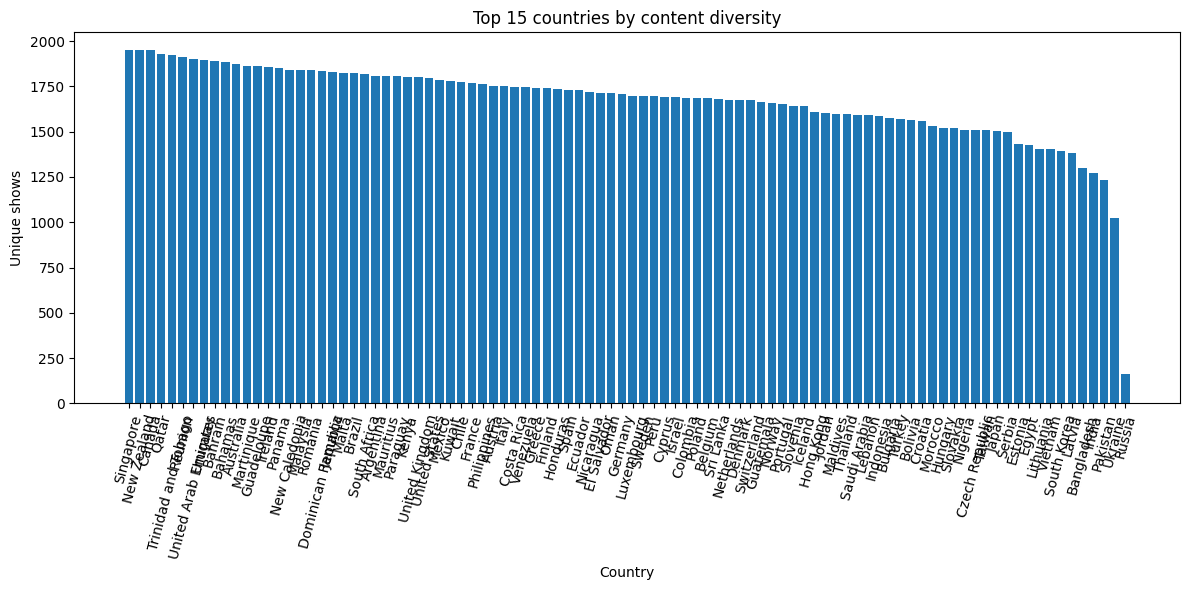

In [ ]:
# Need to fix later
plt.figure(figsize=(12,6))
plt.bar(top_diversity_df["country_name"], top_diversity_df["unique_shows"])
plt.title("Top 15 countries by content diversity")
plt.xlabel("Country")
plt.ylabel("Unique shows")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## Nordic Country Focused Analysis using the global_weekly dataset

## 🎯 Context (Important)

Each row in dataset =
👉 One show in the Top 10
👉 In one country
👉 For one week

So everything calculated is based on **how often and how well a show appears in the Top 10**.

---

# 🧠 1. Appearances

## Definition

Number of weeks a show showed up in the Top 10 during a month.

```sql
COUNT(*)
```

## Simple Explanation

👉 “How many times did this show show up this month?”

## Example

* Appears 4 weeks → appearances = 4
* Appears 1 week → appearances = 1

## What it tells you

* High → show stayed popular for many weeks
* Low → show appeared briefly

---

# 🧠 2. Performance Score

## Definition

A score based on ranking position.

```sql
SUM(11 - weekly_rank)
```

## Simple Explanation

👉 “How strong was the show when it appeared?”

* Rank 1 = 10 points (very strong)
* Rank 10 = 1 point (weak)

## Example

| Week | Rank | Points |
| ---- | ---- | ------ |
| 1    | 1    | 10     |
| 2    | 3    | 8      |
| 3    | 5    | 6      |

Total performance_score = 24

## What it tells you

* High → strong performance (top ranks)
* Low → weak performance (bottom ranks)

---

# 🧠 3. Longevity

## Definition

The maximum total weeks a show has ever been in the Top 10.

```sql
MAX(cumulative_weeks_in_top_10)
```

## Simple Explanation

👉 “Is this a long-lasting hit or just a short trend?”

## Example

* 20 weeks → very popular long-term
* 2 weeks → short-lived

## What it tells you

* High → long-term success
* Low → new or temporary

---

# 🧠 4. Average Rank

## Definition

Average position of the show during the month.

```sql
AVG(weekly_rank)
```

## Simple Explanation

👉 “On average, how high did the show rank?”

## Example

* Avg rank = 2 → very strong
* Avg rank = 8 → weak

## What it tells you

* Lower = better
* Higher = worse

---

# 🔥 Putting It All Together

Each metric shows something different:

| KPI               | Simple Meaning            |
| ----------------- | ------------------------- |
| appearances       | how often it showed up    |
| performance_score | how strong it was         |
| longevity         | how long it lasts overall |
| avg_rank          | how high it ranked        |

---

# 💡 Example Insight

👉 A show can:

* Have **high appearances but low performance_score**
  → It stayed in Top 10 but never at the top

👉 Have **low appearances but high performance_score**
→ It was a strong hit but only for a short time

👉 Have **high longevity**
→ It’s a long-term popular show

---

# 🚀 One Sentence Summary (Use This in Presentations)

> “We measure popularity using frequency (appearances), strength (performance score), and long-term success (longevity).”

---


## Data Frame filter for Sweden

In [23]:
df_sweden = df[df["country_name"] == "Sweden"].copy()

duckdb.register("sweden_weekly", df_sweden)

df_sweden.shape

(4920, 11)

## Which shows dominated Sweden in a given year + month?

In [29]:
sweden_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM sweden_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

sweden_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,Young Royals,4,36.0,4,2.00,1
1,2021,7,Sex/Life,4,29.0,4,3.75,2
2,2021,7,Virgin River,3,28.0,3,1.67,3
3,2021,7,Warcraft,3,26.0,3,2.33,4
4,2021,7,The Magnificent Seven,2,19.0,2,1.50,5
...,...,...,...,...,...,...,...,...
565,2026,3,Bandit,2,16.0,2,3.00,6
566,2026,3,"A Friend, a Murderer",2,16.0,2,3.00,7
567,2026,3,The Dinosaurs,2,16.0,2,3.00,8
568,2026,3,Formula 1: Drive to Survive,2,13.0,2,4.50,9
